# Semiclassical ZPE initialization and molecule-surface MD with MACE

This notebook is a clean and generic version of the original `ZPE_triatomic_MACE_MH1` notebook. It can initialize a molecule with a semiclassical ZPE prescription, build or load a slab, and run molecule-surface dynamics. By default, the slab is a built `4x4x3` graphite slab.


In [57]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "models").exists() and (PROJECT_ROOT.parent / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.environ.setdefault("TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD", "1")

import matplotlib.pyplot as plt
import numpy as np
from itertools import permutations
from ase import units
from ase.data import atomic_numbers, covalent_radii
from ase.build import molecule
from ase.io import Trajectory, read, write
from ase.md.nvtberendsen import NVTBerendsen
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation
from ase.md.verlet import VelocityVerlet
from ase.optimize import BFGS
from ase.visualize import view
from mace.calculators import mace_mp
from tqdm.auto import tqdm
from IPython.display import display
try:
    import nglview as nv
    HAVE_NGLVIEW = True
except Exception:
    HAVE_NGLVIEW = False

MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs" / "02_mace_molecule_surface_zpe"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

try:
    from ase.md.nose_hoover_chain import NoseHooverChainNVT
    HAVE_NHC = True
except Exception:
    HAVE_NHC = False

FOUNDATION_HEADS = {
    "omat_pbe": "General materials.",
    "oc20_usemppbe": "Surfaces and adsorbates.",
    "rgd1_b3lyp": "Reaction-focused chemistry.",
    "omol": "Organic molecules.",
    "spice_wB97M": "Molecular benchmarking.",
}

def list_local_models(models_dir=MODELS_DIR):
    return sorted(Path(models_dir).glob("*.model"))

def create_mace_calculator(model_path, head=None, device="cpu", default_dtype="float64", dispersion=True):
    kwargs = {
        "model": str(model_path),
        "device": device,
        "default_dtype": default_dtype,
        "dispersion": dispersion,
    }
    if head is not None:
        kwargs["head"] = head
    try:
        return mace_mp(**kwargs)
    except RuntimeError as exc:
        if dispersion and "torch-dftd" in str(exc):
            print("torch-dftd not found; retrying with dispersion=False")
            kwargs["dispersion"] = False
            return mace_mp(**kwargs)
        raise

def optimize_structure(atoms, fmax=0.05, max_steps=200, trajectory_path=None, desc="Optimization", show_progress=True):
    if trajectory_path is not None:
        trajectory_path = Path(trajectory_path)
        trajectory_path.parent.mkdir(parents=True, exist_ok=True)
        optimizer = BFGS(atoms, logfile=None, trajectory=str(trajectory_path))
    else:
        optimizer = BFGS(atoms, logfile=None)
    progress = tqdm(desc=desc, unit="step", disable=not show_progress)
    converged = False
    try:
        for converged in optimizer.irun(fmax=fmax, steps=max_steps):
            progress.update(1)
            if converged:
                break
    finally:
        progress.close()
    if not converged:
        print(f"Warning: {desc} reached the step limit ({max_steps}) before convergence.")
    return atoms

def has_meaningful_velocities(atoms):
    velocities = atoms.get_velocities()
    return velocities is not None and np.all(np.isfinite(velocities)) and np.linalg.norm(velocities) > 1e-8


def is_periodic_system(atoms):
    return bool(np.any(atoms.pbc))

def run_md(atoms, timestep_fs, nsteps, temperature_K=None, traj_path=OUTPUTS_DIR / "md.traj", log_path=OUTPUTS_DIR / "md.log", traj_interval=1, log_interval=10, progress_desc="MD", stop_condition=None):
    traj_path = Path(traj_path)
    log_path = Path(log_path)
    traj_path.parent.mkdir(parents=True, exist_ok=True)
    log_path.parent.mkdir(parents=True, exist_ok=True)

    if has_meaningful_velocities(atoms):
        dyn = VelocityVerlet(atoms, timestep_fs * units.fs)
        md_mode = "NVE"
    else:
        if temperature_K is None:
            raise ValueError("temperature_K is required when the structure has no velocities.")
        MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K)
        Stationary(atoms)
        if not is_periodic_system(atoms):
            ZeroRotation(atoms)
        if HAVE_NHC:
            dyn = NoseHooverChainNVT(atoms, timestep=timestep_fs * units.fs, temperature_K=temperature_K, tchain=3, tdamp=100.0)
            md_mode = "NVT (Nose-Hoover chain)"
        else:
            dyn = NVTBerendsen(atoms, timestep_fs * units.fs, temperature_K=temperature_K, taut=100.0 * units.fs)
            md_mode = "NVT (Berendsen fallback)"

    traj = Trajectory(str(traj_path), "w", atoms)
    log_path.write_text("")

    def log_step():
        epot = atoms.get_potential_energy()
        ekin = atoms.get_kinetic_energy()
        temp = ekin / (1.5 * units.kB * len(atoms))
        with log_path.open("a", encoding="utf-8") as handle:
            handle.write(f"{dyn.nsteps:6d}  Epot {epot: .8f}  Ekin {ekin: .8f}  Etot {epot + ekin: .8f}  T {temp: .2f}" + "\n")

    dyn.attach(traj.write, interval=traj_interval)
    dyn.attach(log_step, interval=log_interval)

    stopped_early = False
    stop_reason = None
    progress = tqdm(total=nsteps, desc=f"{progress_desc} [{md_mode}]", unit="step")
    try:
        for _ in range(nsteps):
            dyn.run(1)
            progress.update(1)
            if stop_condition is not None and stop_condition(atoms, dyn.nsteps):
                stopped_early = True
                stop_reason = "stop_condition"
                break
    finally:
        progress.close()
        traj.close()
    return md_mode, traj_path, log_path, dyn.nsteps, stopped_early, stop_reason

def export_xyz(traj_path, xyz_path):
    traj_path = Path(traj_path)
    xyz_path = Path(xyz_path)
    xyz_path.parent.mkdir(parents=True, exist_ok=True)
    frames = Trajectory(str(traj_path))
    write(str(xyz_path), frames, format="xyz")


def shortest_pair_distances(atoms, mic=False, max_pairs=8):
    distances = []
    n_atoms = len(atoms)
    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            distance = atoms.get_distance(i, j, mic=mic)
            distances.append((distance, i, j))
    distances.sort(key=lambda item: item[0])
    return distances[:max_pairs]


def z_layer_positions(atoms, tolerance=0.25):
    z_values = sorted(float(z) for z in atoms.positions[:, 2])
    if not z_values:
        return []
    layers = [[z_values[0]]]
    for z in z_values[1:]:
        if abs(z - np.mean(layers[-1])) <= tolerance:
            layers[-1].append(z)
        else:
            layers.append([z])
    return [float(np.mean(layer)) for layer in layers]


def summarize_molecule_geometry(atoms, label="Molecule"):
    print(f"{label} summary")
    print(f"  Formula              : {atoms.get_chemical_formula()}")
    print(f"  Number of atoms      : {len(atoms)}")
    if len(atoms) >= 2:
        print("  Shortest distances   :")
        for distance, i, j in shortest_pair_distances(atoms, mic=False, max_pairs=min(8, len(atoms) * (len(atoms) - 1) // 2)):
            print(f"    {i:3d}-{j:3d} ({atoms[i].symbol}-{atoms[j].symbol}) : {distance:.4f} A")


def summarize_slab_geometry(atoms, label="Slab"):
    lengths = atoms.cell.lengths()
    angles = atoms.cell.angles()
    print(f"{label} summary")
    print(f"  Formula              : {atoms.get_chemical_formula()}")
    print(f"  Number of atoms      : {len(atoms)}")
    print(f"  Cell lengths (A)     : a={lengths[0]:.4f}, b={lengths[1]:.4f}, c={lengths[2]:.4f}")
    print(f"  Cell angles (deg)    : alpha={angles[0]:.2f}, beta={angles[1]:.2f}, gamma={angles[2]:.2f}")
    print(f"  PBC                  : {tuple(bool(x) for x in atoms.pbc)}")
    builder = atoms.info.get("slab_builder")
    if builder is not None:
        print(f"  Builder              : {builder}")
    conventional_a = conventional_lattice_constant_from_metadata(atoms)
    if conventional_a is not None:
        print(f"  Lattice constant (A) : {conventional_a:.4f}")
    elif atoms.info.get("slab_a_input") is not None:
        print(f"  Lattice constant (A) : {atoms.info['slab_a_input']:.4f} (input)")
    layer_positions = z_layer_positions(atoms)
    if len(layer_positions) >= 2:
        spacings = np.diff(layer_positions)
        print("  Interlayer spacing   :")
        for idx, spacing in enumerate(spacings[:8], start=1):
            print(f"    layer {idx}-{idx+1} : {spacing:.4f} A")
    pair_distances = shortest_pair_distances(atoms, mic=True, max_pairs=8)
    if pair_distances:
        print("  Shortest distances   :")
        for distance, i, j in pair_distances:
            print(f"    {i:3d}-{j:3d} ({atoms[i].symbol}-{atoms[j].symbol}) : {distance:.4f} A")



def show_atoms(atoms, label="structure"):
    try:
        obj = view(atoms, viewer="x3d")
        if obj is not None:
            display(obj)
        return obj
    except Exception as exc:
        fallback = OUTPUTS_DIR / f"{label}.xyz"
        write(fallback, atoms)
        print(f"Visualization fallback written to {fallback} ({exc})")
        return None


def make_interactive_trajectory_viewer(traj_path, label="trajectory"):
    traj_path = Path(traj_path)
    if not traj_path.exists():
        print(f"Trajectory file not found: {traj_path}")
        return None
    if not HAVE_NGLVIEW:
        print("nglview is not available; install it to get an interactive trajectory player.")
        print(f"Trajectory saved at: {traj_path}")
        return None
    traj = Trajectory(str(traj_path))
    if len(traj) == 0:
        print(f"No frames in trajectory: {traj_path}")
        return None
    view_widget = nv.show_asetraj(traj)
    try:
        view_widget.clear_representations()
        view_widget.add_ball_and_stick()
        view_widget.center()
        view_widget.layout.width = "100%"
        view_widget.layout.height = "600px"
        if hasattr(view_widget, "player"):
            try:
                view_widget.player.step = 1
                view_widget.player.delay = 100
                view_widget.player.sync_frame = True
            except Exception:
                pass
    except Exception:
        pass
    return view_widget

def parse_md_log(log_path):
    steps, epot, ekin, etot, temp = [], [], [], [], []
    text = Path(log_path).read_text()
    text = text.replace("\\n", "\n")
    for line in text.splitlines():
        parts = line.split()
        if not parts:
            continue
        steps.append(int(parts[0]))
        epot.append(float(parts[2]))
        ekin.append(float(parts[4]))
        etot.append(float(parts[6]))
        temp.append(float(parts[8]))
    return {"steps": np.asarray(steps), "epot": np.asarray(epot), "ekin": np.asarray(ekin), "etot": np.asarray(etot), "temp": np.asarray(temp)}

from ase.build import bcc100, bcc110, bcc111, bulk, fcc100, fcc110, fcc111, graphene, hcp0001, surface
from ase.constraints import FixAtoms

def tag_slab_metadata(slab, builder, size, a=None, c=None, symbol=None, crystalstructure=None, miller=None):
    slab.info["slab_builder"] = builder
    slab.info["slab_size"] = tuple(size)
    if a is not None:
        slab.info["slab_a_input"] = float(a)
    if c is not None:
        slab.info["slab_c_input"] = float(c)
    if symbol is not None:
        slab.info["slab_symbol"] = symbol
    if crystalstructure is not None:
        slab.info["slab_crystalstructure"] = crystalstructure
    if miller is not None:
        slab.info["slab_miller"] = tuple(miller)
    return slab


def build_graphite_slab(size=(4, 4, 3), vacuum=10.0, a=2.46, interlayer=3.35):
    nx, ny, n_layers = size
    layer0 = graphene(formula="C2", a=a, size=(nx, ny, 1), vacuum=None)
    cell_xy = layer0.cell.copy()
    layers = []
    for layer_index in range(n_layers):
        layer = layer0.copy()
        if layer_index % 2 == 1:
            layer.translate((a / np.sqrt(3.0), 0.0, 0.0))
        layer.translate((0.0, 0.0, layer_index * interlayer))
        layers.append(layer)
    slab = layers[0]
    for layer in layers[1:]:
        slab += layer
    cell_z = (n_layers - 1) * interlayer + 2.0 * vacuum + 5.0
    slab.set_cell([cell_xy[0], cell_xy[1], [0.0, 0.0, cell_z]])
    slab.center(axis=2)
    slab.pbc = (True, True, True)
    return tag_slab_metadata(slab, builder="graphite", size=size, a=a, c=interlayer, symbol="C")


def build_slab(builder="graphite", symbol="C", size=(4, 4, 3), vacuum=10.0, a=None, c=None, crystalstructure="fcc", miller=(1, 1, 1)):
    builder = builder.lower()
    if builder == "graphite":
        return build_graphite_slab(size=size, vacuum=vacuum, a=2.46 if a is None else a, interlayer=3.35 if c is None else c)
    if builder == "fcc111":
        slab = fcc111(symbol=symbol, size=size, vacuum=vacuum, a=a, periodic=True)
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol)
    if builder == "fcc100":
        slab = fcc100(symbol=symbol, size=size, vacuum=vacuum, a=a, periodic=True)
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol)
    if builder == "fcc110":
        slab = fcc110(symbol=symbol, size=size, vacuum=vacuum, a=a, periodic=True)
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol)
    if builder in {"bcc100", "bcc001"}:
        slab = bcc100(symbol=symbol, size=size, vacuum=vacuum, a=a, periodic=True)
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol)
    if builder == "bcc110":
        slab = bcc110(symbol=symbol, size=size, vacuum=vacuum, a=a, periodic=True)
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol)
    if builder == "bcc111":
        slab = bcc111(symbol=symbol, size=size, vacuum=vacuum, a=a, periodic=True)
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol)
    if builder == "hcp0001":
        kwargs = {"symbol": symbol, "size": size, "vacuum": vacuum, "periodic": True}
        if a is not None:
            kwargs["a"] = a
        if c is not None:
            kwargs["c"] = c
        slab = hcp0001(**kwargs)
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol)
    if builder == "surface":
        bulk_kwargs = {"name": symbol, "crystalstructure": crystalstructure, "a": a}
        if c is not None:
            bulk_kwargs["c"] = c
        bulk_atoms = bulk(**bulk_kwargs)
        slab = surface(bulk_atoms, miller, layers=size[2], vacuum=vacuum, periodic=True)
        if size[0] != 1 or size[1] != 1:
            slab = slab.repeat((size[0], size[1], 1))
        return tag_slab_metadata(slab, builder=builder, size=size, a=a, c=c, symbol=symbol, crystalstructure=crystalstructure, miller=miller)
    raise ValueError("Unsupported slab builder. Supported builders: graphite, fcc111, fcc100, fcc110, bcc100/bcc001, bcc110, bcc111, hcp0001, surface.")


def conventional_lattice_constant_from_metadata(atoms):
    builder = atoms.info.get("slab_builder")
    size = atoms.info.get("slab_size")
    if builder is None or size is None:
        return None
    nx = int(size[0])
    lengths = atoms.cell.lengths()
    if builder == "graphite":
        return lengths[0] / nx
    if builder == "fcc100":
        return lengths[0] / nx
    if builder == "fcc110":
        return lengths[0] / nx
    if builder == "fcc111":
        return (lengths[0] / nx) * np.sqrt(2.0)
    if builder in {"bcc100", "bcc001"}:
        return lengths[0] / nx
    if builder == "bcc110":
        return lengths[0] / nx
    if builder == "bcc111":
        return (lengths[0] / nx) / np.sqrt(2.0)
    if builder == "hcp0001":
        return lengths[0] / nx
    return None

def select_trajectory_snapshot(traj_path, mode="last", random_seed=None, frame_index=None):
    traj = Trajectory(str(traj_path))
    n_frames = len(traj)
    if n_frames == 0:
        raise ValueError("No frames available in the thermalization trajectory.")
    if mode == "last":
        selected_index = n_frames - 1
    elif mode == "random":
        rng = np.random.default_rng(random_seed)
        selected_index = int(rng.integers(0, n_frames))
    elif mode == "index":
        if frame_index is None:
            raise ValueError("frame_index must be provided when mode='index'.")
        selected_index = int(frame_index)
        if not 0 <= selected_index < n_frames:
            raise ValueError(f"frame_index must be between 0 and {n_frames - 1}.")
    else:
        raise ValueError("mode must be 'last', 'random', or 'index'.")
    atoms = traj[selected_index].copy()
    return atoms, selected_index, n_frames

def prepare_surface(calc, surface_path=None, fmt=None, surface_atoms=None, optimize=False, optimize_fmax=0.02, optimize_max_steps=200, fix_bottom=False, bottom_thickness=1.5, thermalize=False, thermalize_temperature_K=300.0, thermalize_timestep_fs=0.5, thermalize_steps=200, thermalize_traj_interval=1, thermalize_log_interval=10, optimized_surface_path=None, thermalization_traj_path=OUTPUTS_DIR / "surface_thermalization.traj", thermalization_log_path=OUTPUTS_DIR / "surface_thermalization.log", thermalized_snapshot_mode="last", thermalized_snapshot_seed=None, thermalized_snapshot_index=None):
    if surface_atoms is not None:
        slab = surface_atoms.copy()
    elif surface_path is not None:
        slab = read(surface_path, format=fmt) if fmt else read(surface_path)
    else:
        raise ValueError("Provide either surface_path or surface_atoms.")
    slab.calc = calc
    if fix_bottom:
        z = slab.positions[:, 2]
        mask = z < (z.min() + bottom_thickness)
        slab.set_constraint(FixAtoms(mask=mask))
    if optimize:
        optimize_structure(slab, fmax=optimize_fmax, max_steps=optimize_max_steps, desc="Surface optimization")
        if optimized_surface_path is not None:
            optimized_surface_path = Path(optimized_surface_path)
            optimized_surface_path.parent.mkdir(parents=True, exist_ok=True)
            write(optimized_surface_path, slab)
    selected_snapshot_index = None
    n_thermalized_frames = None
    thermalized_atoms = slab
    if thermalize:
        _, thermalization_traj_path, _, _, _, _ = run_md(
            slab,
            timestep_fs=thermalize_timestep_fs,
            nsteps=thermalize_steps,
            temperature_K=thermalize_temperature_K,
            traj_path=thermalization_traj_path,
            log_path=thermalization_log_path,
            traj_interval=thermalize_traj_interval,
            log_interval=thermalize_log_interval,
            progress_desc="Surface thermalization",
        )
        thermalized_atoms, selected_snapshot_index, n_thermalized_frames = select_trajectory_snapshot(
            thermalization_traj_path,
            mode=thermalized_snapshot_mode,
            random_seed=thermalized_snapshot_seed,
            frame_index=thermalized_snapshot_index,
        )
        thermalized_atoms.calc = calc
    return thermalized_atoms, thermalization_traj_path if thermalize else None, selected_snapshot_index, n_thermalized_frames

def is_linear_molecule(atoms, abs_tol=1e-6, rel_tol=1e-3):
    centered = atoms.get_positions() - atoms.get_center_of_mass()
    _, singular_values, _ = np.linalg.svd(centered, full_matrices=False)
    if len(singular_values) < 2:
        return True
    largest = float(np.max(singular_values))
    if largest <= abs_tol:
        return True
    return float(singular_values[1]) <= max(abs_tol, rel_tol * largest)

def get_vibrational_mode_info(atoms, linear=None):
    ndof = 3 * len(atoms)
    if linear is None:
        linear = is_linear_molecule(atoms)
    linear = bool(linear)
    n_zero = 5 if linear else 6
    return {"ndof": ndof, "linear": linear, "n_zero": n_zero, "n_vib": ndof - n_zero}


def infer_effective_linearity(initial_atoms, optimized_atoms):
    initial_linear = is_linear_molecule(initial_atoms)
    optimized_linear = is_linear_molecule(optimized_atoms)
    return {
        "initial_linear": bool(initial_linear),
        "optimized_linear": bool(optimized_linear),
        # Preserve linear treatment if the input geometry is linear, even if optimization
        # introduces a tiny numerical bend.
        "effective_linear": bool(initial_linear or optimized_linear),
    }

def build_and_optimize_molecule(calc, molecule_source, from_file=False, fmax=0.005, max_steps=200):
    mol = read(molecule_source) if from_file else molecule(molecule_source)
    mol.calc = calc
    optimize_structure(mol, fmax=fmax, max_steps=max_steps, desc="Molecule optimization")
    return mol

def compute_hessian(atoms, delta=0.005):
    ndof = 3 * len(atoms)
    hessian = np.zeros((ndof, ndof))
    pos0 = atoms.get_positions().copy()
    progress = tqdm(total=ndof, desc="Hessian finite differences", unit="dof")
    try:
        for j in range(ndof):
            iat, idir = divmod(j, 3)
            pos_plus = pos0.copy()
            pos_plus[iat, idir] += delta
            atoms.set_positions(pos_plus)
            f_plus = atoms.get_forces().reshape(-1)
            pos_minus = pos0.copy()
            pos_minus[iat, idir] -= delta
            atoms.set_positions(pos_minus)
            f_minus = atoms.get_forces().reshape(-1)
            hessian[:, j] = -(f_plus - f_minus) / (2.0 * delta)
            atoms.set_positions(pos0)
            progress.update(1)
    finally:
        progress.close()
    return 0.5 * (hessian + hessian.T)

def compute_normal_modes(atoms, hessian):
    masses = atoms.get_masses()
    masses_dof = np.repeat(masses, 3)
    sqrt_masses = np.sqrt(masses_dof)
    hessian_mw = hessian / np.outer(sqrt_masses, sqrt_masses)
    eigvals, eigvecs = np.linalg.eigh(hessian_mw)
    ev_to_j = 1.602176634e-19
    amu_to_kg = 1.66053906660e-27
    ang_to_m = 1.0e-10
    c_cm_s = 2.99792458e10
    lambda_to_omega2 = ev_to_j / (amu_to_kg * ang_to_m**2)
    freqs_cm1 = np.zeros_like(eigvals)
    for i, eig in enumerate(eigvals):
        if eig != 0.0:
            omega = np.sqrt(abs(eig) * lambda_to_omega2)
            freqs_cm1[i] = (1.0 if eig > 0 else -1.0) * omega / (2 * np.pi * c_cm_s)
    return freqs_cm1, eigvecs, masses_dof, eigvals

def semiclassical_zpe_init(atoms, freqs_cm1, eigvecs, masses_dof, eigvals, v_quantum=None, seed=None, linear=None):
    info = get_vibrational_mode_info(atoms, linear=linear)
    ndof = info["ndof"]
    n_zero = info["n_zero"]
    n_vib = info["n_vib"]
    if v_quantum is None:
        v_quantum = [0] * n_vib
    if len(v_quantum) != n_vib:
        raise ValueError(f"Expected {n_vib} vibrational quantum numbers, got {len(v_quantum)}.")
    rng = np.random.default_rng(seed)
    hbar_ev_fs = 0.6582119514
    ev_to_j = 1.602176634e-19
    amu_to_kg = 1.66053906660e-27
    ang_to_m = 1.0e-10
    fs_to_s = 1.0e-15
    lambda_to_omega2_fs2 = (ev_to_j / (amu_to_kg * ang_to_m**2)) * (fs_to_s**2)
    kconv = amu_to_kg * (ang_to_m / fs_to_s) ** 2 / ev_to_j
    delta_q = np.zeros(ndof)
    delta_qdot = np.zeros(ndof)
    for k, vk in enumerate(v_quantum):
        mode_idx = n_zero + k
        lam = eigvals[mode_idx]
        if lam <= 0:
            continue
        omega_fs = np.sqrt(lam * lambda_to_omega2_fs2)
        energy = hbar_ev_fs * omega_fs * (vk + 0.5)
        phase = rng.uniform(0.0, 2.0 * np.pi)
        delta_q[mode_idx] = np.sqrt(2.0 * energy / lam) * np.cos(phase)
        delta_qdot[mode_idx] = -np.sqrt(2.0 * energy / kconv) * np.sin(phase)
    sqrt_masses = np.sqrt(masses_dof)
    delta_pos = (eigvecs @ delta_q / sqrt_masses).reshape(len(atoms), 3)
    delta_vel = (eigvecs @ delta_qdot / sqrt_masses).reshape(len(atoms), 3)
    return delta_pos, delta_vel

def remove_com_and_angular_momentum(atoms, delta_pos, delta_vel):
    masses = atoms.get_masses()
    total_mass = masses.sum()
    pos = atoms.get_positions()
    v_cm = (masses[:, None] * delta_vel).sum(axis=0) / total_mass
    delta_vel = delta_vel - v_cm[None, :]
    ang_mom = np.zeros(3)
    for i in range(len(atoms)):
        ang_mom += masses[i] * np.cross(pos[i] + delta_pos[i], delta_vel[i])
    com = (masses[:, None] * pos).sum(axis=0) / total_mass
    inertia = np.zeros((3, 3))
    for i in range(len(atoms)):
        r = pos[i] - com
        inertia += masses[i] * (np.dot(r, r) * np.eye(3) - np.outer(r, r))
    omega = np.linalg.pinv(inertia) @ ang_mom
    for i in range(len(atoms)):
        r = pos[i] + delta_pos[i] - com
        delta_vel[i] -= np.cross(omega, r)
    return delta_pos, delta_vel

def compute_modal_zpe_report(atoms, delta_pos, delta_vel, freqs_cm1, eigvecs, masses_dof, eigvals, v_quantum=None, linear=None):
    info = get_vibrational_mode_info(atoms, linear=linear)
    n_zero = info["n_zero"]
    n_vib = info["n_vib"]
    if v_quantum is None:
        v_quantum = [0] * n_vib
    if len(v_quantum) != n_vib:
        raise ValueError(f"Expected {n_vib} vibrational quantum numbers, got {len(v_quantum)}.")
    max_modes = len(eigvals) - n_zero
    if len(v_quantum) > max_modes:
        raise ValueError(f"Too many vibrational quantum numbers for this molecule: got {len(v_quantum)}, but only {max_modes} vibrational modes are available after removing translations/rotations.")
    ev_to_j = 1.602176634e-19
    amu_to_kg = 1.66053906660e-27
    ang_to_m = 1.0e-10
    fs_to_s = 1.0e-15
    hbar_ev_fs = 0.6582119514
    kconv = amu_to_kg * (ang_to_m / fs_to_s) ** 2 / ev_to_j
    lambda_to_omega2_fs2 = (ev_to_j / (amu_to_kg * ang_to_m**2)) * (fs_to_s**2)
    q = eigvecs.T @ (np.sqrt(masses_dof) * delta_pos.reshape(-1))
    qdot = eigvecs.T @ (np.sqrt(masses_dof) * delta_vel.reshape(-1))
    mode_kinetic = 0.5 * qdot**2 * kconv
    mode_potential = np.zeros_like(mode_kinetic)
    target_total = 0.0
    details = []
    for k, vk in enumerate(v_quantum):
        mode_idx = n_zero + k
        lam = eigvals[mode_idx]
        if lam <= 0:
            continue
        omega_fs = np.sqrt(lam * lambda_to_omega2_fs2)
        target_total += hbar_ev_fs * omega_fs * (vk + 0.5)
        mode_potential[mode_idx] = 0.5 * lam * q[mode_idx] ** 2
    mode_total = mode_kinetic + mode_potential
    for k, mode_idx in enumerate(range(n_zero, len(freqs_cm1))):
        details.append({"vibrational_mode_index": int(k), "frequency_cm1": float(freqs_cm1[mode_idx]), "total_eV": float(mode_total[mode_idx])})
    return {"target_total_eV": float(target_total), "modal_kinetic_eV": float(mode_kinetic[n_zero:].sum()), "modal_potential_eV": float(mode_potential[n_zero:].sum()), "modal_total_eV": float(mode_total[n_zero:].sum()), "external_leak_eV": float(mode_total[:n_zero].sum()), "mode_details": details}

def add_rotational_temperature(atoms, temperature_K, seed=None, linear=None, inertia_tol=1e-8):
    if temperature_K is None or temperature_K <= 0:
        return {"applied": False, "temperature_K": None, "rotational_dof": 0, "target_energy_eV": 0.0, "sampled_energy_eV": 0.0, "moments_amu_A2": [], "omega_principal_fs^-1": []}
    if linear is None:
        linear = is_linear_molecule(atoms)
    masses = atoms.get_masses()
    com = atoms.get_center_of_mass()
    rel = atoms.get_positions() - com
    inertia = np.zeros((3, 3))
    for mass, r in zip(masses, rel):
        inertia += mass * (np.dot(r, r) * np.eye(3) - np.outer(r, r))
    moments, principal_axes = np.linalg.eigh(inertia)
    order = np.argsort(moments)
    moments = moments[order]
    principal_axes = principal_axes[:, order]
    active_axes = [idx for idx, moment in enumerate(moments) if moment > inertia_tol]
    if linear and len(active_axes) > 2:
        active_axes = active_axes[-2:]
    rng = np.random.default_rng(seed)
    ev_to_j = 1.602176634e-19
    amu_to_kg = 1.66053906660e-27
    ang_to_m = 1.0e-10
    fs_to_s = 1.0e-15
    kconv = amu_to_kg * (ang_to_m / fs_to_s) ** 2 / ev_to_j
    omega_principal = np.zeros(3)
    for idx in active_axes:
        sigma = np.sqrt(units.kB * temperature_K / (moments[idx] * kconv))
        omega_principal[idx] = rng.normal(scale=sigma)
    omega_cart = principal_axes @ omega_principal
    delta_vel = np.cross(omega_cart, rel)
    velocities = atoms.get_velocities()
    if velocities is None:
        velocities = np.zeros((len(atoms), 3))
    atoms.set_velocities(velocities + delta_vel / units.fs)
    rotational_energy = 0.5 * np.sum(moments * omega_principal**2) * kconv
    rotational_dof = len(active_axes)
    return {
        "applied": True,
        "temperature_K": float(temperature_K),
        "rotational_dof": int(rotational_dof),
        "target_energy_eV": float(0.5 * rotational_dof * units.kB * temperature_K),
        "sampled_energy_eV": float(rotational_energy),
        "moments_amu_A2": [float(value) for value in moments],
        "omega_principal_fs^-1": [float(value) for value in omega_principal],
    }

def initialize_molecule_zpe(calc, molecule_source, from_file=False, v_quantum=None, seed=None, delta=0.005, fmax=0.005, optimize_max_steps=200, optimized_geometry_path=None, rotational_temperature_K=None, rotational_seed=None):
    initial_mol = read(molecule_source) if from_file else molecule(molecule_source)
    mol = initial_mol.copy()
    mol.calc = calc
    optimize_structure(mol, fmax=fmax, max_steps=optimize_max_steps, desc="Molecule optimization")
    optimized_atoms = mol.copy()
    if optimized_geometry_path is not None:
        optimized_geometry_path = Path(optimized_geometry_path)
        optimized_geometry_path.parent.mkdir(parents=True, exist_ok=True)
        write(optimized_geometry_path, optimized_atoms)
    linearity = infer_effective_linearity(initial_mol, optimized_atoms)
    info = get_vibrational_mode_info(mol, linear=linearity["effective_linear"])
    if v_quantum is None:
        v_quantum = [0] * info["n_vib"]
    if len(v_quantum) != info["n_vib"]:
        raise ValueError(f"Expected {info['n_vib']} vibrational quantum numbers for {molecule_source}, got {len(v_quantum)}.")
    hessian = compute_hessian(mol, delta=delta)
    freqs_cm1, eigvecs, masses_dof, eigvals = compute_normal_modes(mol, hessian)
    delta_pos, delta_vel = semiclassical_zpe_init(mol, freqs_cm1, eigvecs, masses_dof, eigvals, v_quantum=v_quantum, seed=seed, linear=linearity["effective_linear"])
    delta_pos, delta_vel = remove_com_and_angular_momentum(mol, delta_pos, delta_vel)
    pos_eq = mol.get_positions().copy()
    mol.set_positions(pos_eq + delta_pos)
    mol.set_velocities(delta_vel / units.fs)
    report = compute_modal_zpe_report(mol, delta_pos, delta_vel, freqs_cm1, eigvecs, masses_dof, eigvals, v_quantum=v_quantum, linear=linearity["effective_linear"])
    rotational_report = add_rotational_temperature(mol, rotational_temperature_K, seed=rotational_seed, linear=linearity["effective_linear"])
    return mol, {"freqs_cm1": freqs_cm1, "linear": info["linear"], "initial_linear": linearity["initial_linear"], "optimized_linear": linearity["optimized_linear"], "effective_linear": linearity["effective_linear"], "n_zero": info["n_zero"], "n_vib": info["n_vib"], "zpe_report": report, "rotational_report": rotational_report, "optimized_atoms": optimized_atoms, "eigvecs": eigvecs, "masses_dof": masses_dof, "eigvals": eigvals}

def velocity_from_incident_energy_eV(atoms, energy_eV, direction=(0.0, 0.0, -1.0)):
    direction = np.asarray(direction, dtype=float)
    direction /= np.linalg.norm(direction)
    ev_to_j = 1.602176634e-19
    amu_to_kg = 1.66053906660e-27
    ang_to_m = 1.0e-10
    fs_to_s = 1.0e-15
    total_mass_kg = atoms.get_masses().sum() * amu_to_kg
    velocity_m_s = np.sqrt(2.0 * energy_eV * ev_to_j / total_mass_kg)
    velocity_ang_fs = velocity_m_s * (fs_to_s / ang_to_m)
    return (velocity_ang_fs / units.fs) * direction


def get_center_of_mass_velocity(atoms):
    velocities = atoms.get_velocities()
    if velocities is None:
        return np.zeros(3)
    masses = atoms.get_masses()
    return (masses[:, None] * velocities).sum(axis=0) / masses.sum()


def set_center_of_mass_velocity(atoms, target_velocity):
    target_velocity = np.asarray(target_velocity, dtype=float)
    velocities = atoms.get_velocities()
    if velocities is None:
        velocities = np.zeros((len(atoms), 3))
    current_com_velocity = get_center_of_mass_velocity(atoms)
    atoms.set_velocities(velocities + (target_velocity - current_com_velocity)[None, :])
    return atoms

def random_rotation_matrix(rng):
    u1, u2, u3 = rng.random(3)
    qx = np.sqrt(1.0 - u1) * np.sin(2 * np.pi * u2)
    qy = np.sqrt(1.0 - u1) * np.cos(2 * np.pi * u2)
    qz = np.sqrt(u1) * np.sin(2 * np.pi * u3)
    qw = np.sqrt(u1) * np.cos(2 * np.pi * u3)
    return np.array([[1 - 2 * (qy**2 + qz**2), 2 * (qx * qy - qz * qw), 2 * (qx * qz + qy * qw)], [2 * (qx * qy + qz * qw), 1 - 2 * (qx**2 + qz**2), 2 * (qy * qz - qx * qw)], [2 * (qx * qz - qy * qw), 2 * (qy * qz + qx * qw), 1 - 2 * (qx**2 + qy**2)]])

def place_molecule_above_slab(mol, slab, height=4.0, xy_mode="center", xy_target=None, random_orientation=True, orientation_seed=None):
    if random_orientation:
        rng = np.random.default_rng(orientation_seed)
        rotation = random_rotation_matrix(rng)
        com = mol.get_center_of_mass()
        rel = mol.get_positions() - com
        mol.set_positions(com + rel @ rotation.T)
        velocities = mol.get_velocities()
        if velocities is not None:
            mol.set_velocities(velocities @ rotation.T)
    if xy_mode == "center":
        xy = slab.positions[:, :2].mean(axis=0)
    elif xy_mode == "custom":
        xy = np.asarray(xy_target, dtype=float)
    else:
        raise ValueError("xy_mode must be 'center' or 'custom'.")
    target_com = np.array([xy[0], xy[1], slab.positions[:, 2].max() + height])
    mol.positions += target_com - mol.get_center_of_mass()
    return mol

def build_slab_molecule_system(slab, mol, calc):
    system = slab + mol
    system.calc = calc
    velocities = np.zeros((len(system), 3))
    slab_vel = slab.get_velocities()
    if slab_vel is not None:
        velocities[:len(slab)] = slab_vel
    mol_vel = mol.get_velocities()
    if mol_vel is not None:
        velocities[-len(mol):] = mol_vel
    system.set_velocities(velocities)
    return system


def get_surface_top_z(atoms, slab_indices):
    slab_positions = atoms[slab_indices].get_positions()
    return float(slab_positions[:, 2].max())


def get_molecule_height_above_surface(atoms, slab_indices, molecule_indices):
    molecule_com_z = atoms[molecule_indices].get_center_of_mass()[2]
    surface_top_z = get_surface_top_z(atoms, slab_indices)
    return float(molecule_com_z - surface_top_z)


def make_scattering_stop_condition(slab_indices, molecule_indices, initial_height, tolerance=0.05, require_descent=True):
    state = {
        "descended": not require_descent,
        "initial_height": float(initial_height),
        "current_height": float(initial_height),
        "stop_step": None,
    }

    def stop_condition(atoms, step):
        current_height = get_molecule_height_above_surface(atoms, slab_indices, molecule_indices)
        state["current_height"] = float(current_height)
        if require_descent and not state["descended"] and current_height < initial_height - tolerance:
            state["descended"] = True
        if state["descended"] and current_height >= initial_height - tolerance:
            state["stop_step"] = int(step)
            return True
        return False

    return stop_condition, state

def kinetic_energy_from_velocities(masses, velocities_ang_fs):
    ev_to_j = 1.602176634e-19
    amu_to_kg = 1.66053906660e-27
    ang_to_m = 1.0e-10
    fs_to_s = 1.0e-15
    kconv = amu_to_kg * (ang_to_m / fs_to_s) ** 2 / ev_to_j
    return 0.5 * np.sum(masses[:, None] * velocities_ang_fs**2) * kconv

def get_active_rotational_axes(moments, linear=False, inertia_tol=1e-8):
    active_axes = [idx for idx, moment in enumerate(moments) if moment > inertia_tol]
    if linear and len(active_axes) > 2:
        active_axes = active_axes[-2:]
    return active_axes

def analyze_molecule_frame(atoms, molecule_indices, slab_indices=None, incident_direction=(0.0, 0.0, -1.0), linear=None, inertia_tol=1e-8):
    molecule_indices = np.asarray(molecule_indices, dtype=int)
    masses = atoms.get_masses()[molecule_indices]
    positions = atoms.get_positions()[molecule_indices]
    velocities = atoms.get_velocities()
    if velocities is None:
        velocities = np.zeros((len(atoms), 3))
    velocities_ang_fs = velocities[molecule_indices] * units.fs
    total_mass = masses.sum()
    com = (masses[:, None] * positions).sum(axis=0) / total_mass
    com_velocity = (masses[:, None] * velocities_ang_fs).sum(axis=0) / total_mass
    rel_pos = positions - com
    rel_vel = velocities_ang_fs - com_velocity
    total_kinetic = kinetic_energy_from_velocities(masses, velocities_ang_fs)
    conversion = 1.66053906660e-27 * (1.0e-10 / 1.0e-15) ** 2 / 1.602176634e-19
    translational_kinetic = 0.5 * total_mass * np.dot(com_velocity, com_velocity) * conversion
    inertia = np.zeros((3, 3))
    for mass, r in zip(masses, rel_pos):
        inertia += mass * (np.dot(r, r) * np.eye(3) - np.outer(r, r))
    ang_mom = np.sum(masses[:, None] * np.cross(rel_pos, rel_vel), axis=0)
    moments, principal_axes = np.linalg.eigh(inertia)
    order = np.argsort(moments)
    moments = moments[order]
    principal_axes = principal_axes[:, order]
    angular_momentum_principal = principal_axes.T @ ang_mom
    if linear is None:
        linear = is_linear_molecule(atoms[molecule_indices])
    active_axes = get_active_rotational_axes(moments, linear=linear, inertia_tol=inertia_tol)
    rotational_kinetic = 0.0
    omega_principal = np.zeros(3)
    for idx in active_axes:
        if moments[idx] <= inertia_tol:
            continue
        omega_principal[idx] = angular_momentum_principal[idx] / moments[idx]
        rotational_kinetic += 0.5 * moments[idx] * omega_principal[idx] ** 2 * conversion
    internal_kinetic = total_kinetic - translational_kinetic - rotational_kinetic
    direction = np.asarray(incident_direction, dtype=float)
    direction /= np.linalg.norm(direction)
    normal_speed = float(np.dot(com_velocity, direction))
    normal_velocity = normal_speed * direction
    tangential_velocity = com_velocity - normal_velocity
    normal_kinetic = 0.5 * total_mass * normal_speed ** 2 * conversion
    tangential_kinetic = 0.5 * total_mass * np.dot(tangential_velocity, tangential_velocity) * conversion
    rotational_temperature = 0.0
    if active_axes:
        rotational_temperature = 2.0 * rotational_kinetic / (len(active_axes) * units.kB)
    height = None
    if slab_indices is not None:
        height = get_molecule_height_above_surface(atoms, slab_indices, molecule_indices)
    return {
        "com_x_A": float(com[0]),
        "com_y_A": float(com[1]),
        "com_z_A": float(com[2]),
        "height_A": None if height is None else float(height),
        "com_speed_A_fs": float(np.linalg.norm(com_velocity)),
        "normal_speed_A_fs": float(normal_speed),
        "total_kinetic_eV": float(total_kinetic),
        "translational_kinetic_eV": float(translational_kinetic),
        "normal_kinetic_eV": float(normal_kinetic),
        "tangential_kinetic_eV": float(tangential_kinetic),
        "rotational_kinetic_eV": float(rotational_kinetic),
        "internal_kinetic_eV": float(internal_kinetic),
        "rotational_temperature_K": float(rotational_temperature),
        "rotational_dof": int(len(active_axes)),
        "moments_amu_A2": [float(value) for value in moments],
        "omega_principal_fs^-1": [float(value) for value in omega_principal],
    }

def analyze_molecule_trajectory(traj_path, molecule_indices, slab_indices=None, timestep_fs=1.0, traj_interval=1, incident_direction=(0.0, 0.0, -1.0), linear=None, initial_atoms=None):
    records = []
    steps = []
    times_fs = []
    if initial_atoms is not None:
        records.append(analyze_molecule_frame(initial_atoms, molecule_indices, slab_indices=slab_indices, incident_direction=incident_direction, linear=linear))
        steps.append(0)
        times_fs.append(0.0)
    traj = Trajectory(str(traj_path))
    for frame_idx, atoms in enumerate(traj, start=1):
        records.append(analyze_molecule_frame(atoms, molecule_indices, slab_indices=slab_indices, incident_direction=incident_direction, linear=linear))
        step = frame_idx * traj_interval
        steps.append(step)
        times_fs.append(step * timestep_fs)
    if not records:
        raise ValueError(f"No frames found in trajectory: {traj_path}")
    analysis = {"step": np.asarray(steps), "time_fs": np.asarray(times_fs, dtype=float)}
    for key in records[0]:
        values = [record[key] for record in records]
        if isinstance(values[0], list):
            analysis[key] = np.asarray(values, dtype=float)
        elif values[0] is None:
            analysis[key] = np.asarray(values, dtype=object)
        else:
            analysis[key] = np.asarray(values, dtype=float)
    return analysis

def kabsch_rotation(reference_positions, target_positions):
    covariance = target_positions.T @ reference_positions
    u, _, vh = np.linalg.svd(covariance)
    rotation = u @ vh
    if np.linalg.det(rotation) < 0:
        u[:, -1] *= -1.0
        rotation = u @ vh
    return rotation

def build_bond_adjacency(positions, atomic_numbers_array, scale=1.2, min_cutoff=0.4):
    n_atoms = len(atomic_numbers_array)
    adjacency = [set() for _ in range(n_atoms)]
    for i in range(n_atoms):
        zi = int(atomic_numbers_array[i])
        ri = covalent_radii[zi]
        for j in range(i + 1, n_atoms):
            zj = int(atomic_numbers_array[j])
            rj = covalent_radii[zj]
            cutoff = max(min_cutoff, scale * (ri + rj))
            if np.linalg.norm(positions[i] - positions[j]) <= cutoff:
                adjacency[i].add(j)
                adjacency[j].add(i)
    return adjacency

def build_equivalent_atom_groups(reference_atoms):
    positions = reference_atoms.get_positions().copy()
    symbols = reference_atoms.get_chemical_symbols()
    numbers = reference_atoms.get_atomic_numbers().copy()
    adjacency = build_bond_adjacency(positions, numbers)
    groups = {}
    for idx, symbol in enumerate(symbols):
        neighbors = sorted(adjacency[idx])
        neighbor_symbols = tuple(sorted(symbols[j] for j in neighbors))
        parent_signatures = []
        for neighbor in neighbors:
            parent_neighbors = sorted(j for j in adjacency[neighbor] if j != idx)
            parent_signatures.append((
                symbols[neighbor],
                tuple(sorted(symbols[j] for j in parent_neighbors)),
            ))
        key = (symbol, neighbor_symbols, tuple(sorted(parent_signatures)))
        groups.setdefault(key, []).append(idx)
    return [group for group in groups.values() if len(group) > 1]

def reorder_equivalent_atoms(reference_centered, target_centered, velocities_ang_fs, equivalent_groups, max_iter=2):
    if not equivalent_groups:
        return target_centered, velocities_ang_fs
    reordered_target = target_centered.copy()
    reordered_vel = velocities_ang_fs.copy()
    for _ in range(max_iter):
        changed = False
        for group in equivalent_groups:
            group_idx = np.asarray(group, dtype=int)
            target_group = reordered_target[group_idx].copy()
            vel_group = reordered_vel[group_idx].copy()
            best_perm = tuple(range(len(group_idx)))
            best_cost = np.inf
            for perm in permutations(range(len(group_idx))):
                trial_target = reordered_target.copy()
                trial_target[group_idx] = target_group[list(perm)]
                trial_rotation = kabsch_rotation(reference_centered, trial_target)
                trial_aligned = trial_target @ trial_rotation
                cost = np.sum((trial_aligned - reference_centered) ** 2)
                if cost < best_cost:
                    best_cost = cost
                    best_perm = perm
            perm_idx = np.asarray(best_perm, dtype=int)
            if not np.array_equal(perm_idx, np.arange(len(group_idx))):
                reordered_target[group_idx] = target_group[perm_idx]
                reordered_vel[group_idx] = vel_group[perm_idx]
                changed = True
        if not changed:
            break
    return reordered_target, reordered_vel

def align_molecule_to_reference(reference_positions, positions, velocities_ang_fs, masses, equivalent_groups=None):
    total_mass = masses.sum()
    ref_com = (masses[:, None] * reference_positions).sum(axis=0) / total_mass
    pos_com = (masses[:, None] * positions).sum(axis=0) / total_mass
    ref_centered = reference_positions - ref_com
    pos_centered = positions - pos_com
    vel_centered = velocities_ang_fs.copy()
    pos_centered, vel_centered = reorder_equivalent_atoms(ref_centered, pos_centered, vel_centered, equivalent_groups or [])
    rotation = kabsch_rotation(ref_centered, pos_centered)
    aligned_pos = pos_centered @ rotation
    aligned_vel = vel_centered @ rotation
    return aligned_pos, aligned_vel, rotation, ref_centered

def project_vibrational_modes(reference_positions, positions, velocities_ang_fs, masses, eigvecs, masses_dof, eigvals, n_zero, linear=None, inertia_tol=1e-8, equivalent_groups=None):
    aligned_pos, aligned_vel, _, ref_centered = align_molecule_to_reference(reference_positions, positions, velocities_ang_fs, masses, equivalent_groups=equivalent_groups)
    displacement = aligned_pos - ref_centered
    total_mass = masses.sum()
    com_velocity = (masses[:, None] * aligned_vel).sum(axis=0) / total_mass
    internal_vel = aligned_vel - com_velocity
    inertia = np.zeros((3, 3))
    for mass, r in zip(masses, aligned_pos):
        inertia += mass * (np.dot(r, r) * np.eye(3) - np.outer(r, r))
    ang_mom = np.sum(masses[:, None] * np.cross(aligned_pos, internal_vel), axis=0)
    omega = np.linalg.pinv(inertia, rcond=inertia_tol) @ ang_mom
    vib_vel = internal_vel - np.cross(omega, aligned_pos)
    sqrt_masses = np.sqrt(masses_dof)
    q = eigvecs.T @ (sqrt_masses * displacement.reshape(-1))
    qdot = eigvecs.T @ (sqrt_masses * vib_vel.reshape(-1))
    kconv = 1.66053906660e-27 * (1.0e-10 / 1.0e-15) ** 2 / 1.602176634e-19
    mode_kinetic = 0.5 * qdot**2 * kconv
    mode_potential = 0.5 * np.clip(eigvals, 0.0, None) * q**2
    mode_total = mode_kinetic + mode_potential
    return {
        "q": q,
        "qdot": qdot,
        "mode_kinetic_eV": mode_kinetic,
        "mode_potential_eV": mode_potential,
        "mode_total_eV": mode_total,
        "vibrational_mode_total_eV": mode_total[n_zero:].copy(),
        "vibrational_mode_kinetic_eV": mode_kinetic[n_zero:].copy(),
        "vibrational_mode_potential_eV": mode_potential[n_zero:].copy(),
    }

def analyze_vibrational_mode_trajectory(traj_path, molecule_indices, reference_atoms, eigvecs, masses_dof, eigvals, n_zero, timestep_fs=1.0, traj_interval=1, initial_atoms=None):
    molecule_indices = np.asarray(molecule_indices, dtype=int)
    reference_positions = reference_atoms.get_positions().copy()
    masses = reference_atoms.get_masses().copy()
    equivalent_groups = build_equivalent_atom_groups(reference_atoms)
    records = []
    steps = []
    times_fs = []
    def analyze_atoms(atoms):
        positions = atoms.get_positions()[molecule_indices]
        velocities = atoms.get_velocities()
        if velocities is None:
            velocities = np.zeros((len(atoms), 3))
        velocities_ang_fs = velocities[molecule_indices] * units.fs
        return project_vibrational_modes(reference_positions, positions, velocities_ang_fs, masses, eigvecs, masses_dof, eigvals, n_zero, equivalent_groups=equivalent_groups)
    if initial_atoms is not None:
        records.append(analyze_atoms(initial_atoms))
        steps.append(0)
        times_fs.append(0.0)
    traj = Trajectory(str(traj_path))
    for frame_idx, atoms in enumerate(traj, start=1):
        records.append(analyze_atoms(atoms))
        step = frame_idx * traj_interval
        steps.append(step)
        times_fs.append(step * timestep_fs)
    if not records:
        raise ValueError(f"No frames found in trajectory: {traj_path}")
    analysis = {"step": np.asarray(steps), "time_fs": np.asarray(times_fs, dtype=float)}
    for key in records[0]:
        analysis[key] = np.asarray([record[key] for record in records], dtype=float)
    return analysis




## Load model


In [58]:
for model_path in list_local_models():
    print(model_path)

MODEL_PATH = MODELS_DIR / "mace-mh-1.model"   # Local MACE checkpoint to load.
MODEL_HEAD = "oc20_usemppbe"                  # Surface/adsorbate head for the foundation model.
DEVICE = "cpu"                                 # 'cpu' or 'cuda'.
DEFAULT_DTYPE = "float32"                      # float64 is slower but safer for optimization.
USE_DISPERSION = True                          # Use D3 dispersion through torch-dftd if available.

for key, description in FOUNDATION_HEADS.items():
    print(f"{key:16s} : {description}")

calc = create_mace_calculator(MODEL_PATH, head=MODEL_HEAD, device=DEVICE, default_dtype=DEFAULT_DTYPE, dispersion=USE_DISPERSION)


/Users/samuel/Desktop/postdoc_PhLAM/codes/Introduction_to_MACE/.venv/lib/python3.14/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


/Users/samuel/Desktop/postdoc_PhLAM/codes/Introduction_to_MACE/models/mace-mh-1.model
omat_pbe         : General materials.
oc20_usemppbe    : Surfaces and adsorbates.
rgd1_b3lyp       : Reaction-focused chemistry.
omol             : Organic molecules.
spice_wB97M      : Molecular benchmarking.
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using TorchDFTD3Calculator for D3 dispersion corrections


## Semiclassical ZPE initialization


In [59]:
MOLECULE_SOURCE = "NO"                                 # ASE molecule name, or a file path if MOLECULE_FROM_FILE=True.
MOLECULE_FROM_FILE = False                             # Read the molecule from a file instead of ASE's molecule builder.
ZPE_SEED = 42                                          # Random seed for the semiclassical ZPE initialization.
V_QUANTUM = None                                       # Vibrational quantum numbers, or None for the ground state. CO2 has 4 vibrational modes.
ROTATIONAL_TEMPERATURE_K = 300                        # Optional classical rotational temperature added on top of the ZPE state.
ROTATIONAL_SEED = 31415                                # Random seed used when ROTATIONAL_TEMPERATURE_K is enabled.
MOLECULE_OPT_FMAX = 0.005                              # Force convergence threshold for molecule optimization (eV/A).
MOLECULE_OPT_MAX_STEPS = 200                           # Maximum number of optimization steps for the molecule.
WRITE_OPTIMIZED_MOLECULE = True                        # Save the optimized molecule before ZPE displacement.
OPTIMIZED_MOLECULE_PATH = OUTPUTS_DIR / "optimized_molecule.xyz"  # Output path for the optimized molecule.
SHOW_OPTIMIZED_MOLECULE = True                         # Visualize the optimized molecule.
SHOW_ZPE_INITIALIZED_MOLECULE = False                   # Visualize the molecule after ZPE initialization.

molecule_atoms, zpe_result = initialize_molecule_zpe(
    calc,
    MOLECULE_SOURCE,
    from_file=MOLECULE_FROM_FILE,
    v_quantum=V_QUANTUM,
    seed=ZPE_SEED,
    fmax=MOLECULE_OPT_FMAX,
    optimize_max_steps=MOLECULE_OPT_MAX_STEPS,
    optimized_geometry_path=OPTIMIZED_MOLECULE_PATH if WRITE_OPTIMIZED_MOLECULE else None,
    rotational_temperature_K=ROTATIONAL_TEMPERATURE_K,
    rotational_seed=ROTATIONAL_SEED,
)

optimized_molecule = zpe_result["optimized_atoms"]
summarize_molecule_geometry(optimized_molecule, label="Optimized molecule")
print(f"Initial geometry linear : {zpe_result['initial_linear']}")
print(f"Optimized geometry linear: {zpe_result['optimized_linear']}")
print(f"Effective linear treatment: {zpe_result['effective_linear']}")
print(f"Vibrational modes used   : {zpe_result['n_vib']}")
rot_report = zpe_result["rotational_report"]
if rot_report["applied"]:
    print(f"Rotational temperature  : {rot_report['temperature_K']:.2f} K")
    print(f"Rotational DOF sampled  : {rot_report['rotational_dof']}")
    print(f"Sampled rotational energy: {rot_report['sampled_energy_eV']:.6f} eV")
else:
    print("Rotational temperature  : disabled")
if SHOW_OPTIMIZED_MOLECULE:
    show_atoms(optimized_molecule, label="optimized_molecule")
if SHOW_ZPE_INITIALIZED_MOLECULE:
    show_atoms(molecule_atoms, label="zpe_initialized_molecule")

vib_freqs = zpe_result["freqs_cm1"][zpe_result["n_zero"]:]
print("Vibrational frequencies (cm^-1):")
for index, frequency in enumerate(vib_freqs, start=1):
    print(f"  nu{index} = {frequency:.2f} cm^-1")


Molecule optimization: 0step [00:00, ?step/s]

Hessian finite differences:   0%|          | 0/6 [00:00<?, ?dof/s]

Optimized molecule summary
  Formula              : NO
  Number of atoms      : 2
  Shortest distances   :
      0-  1 (N-O) : 1.1755 A
Initial geometry linear : True
Optimized geometry linear: True
Effective linear treatment: True
Vibrational modes used   : 1
Rotational temperature  : 300.00 K
Rotational DOF sampled  : 2
Sampled rotational energy: 0.033280 eV


Vibrational frequencies (cm^-1):
  nu1 = 1738.98 cm^-1


Target ZPE          : 0.107803 eV
Modal total energy  : 0.107803 eV
Modal kinetic energy: 0.105379 eV
Modal potential     : 0.002424 eV
External leakage    : 2.955442e-35 eV
Target rotational energy : 0.025852 eV
Sampled rotational energy: 0.033280 eV


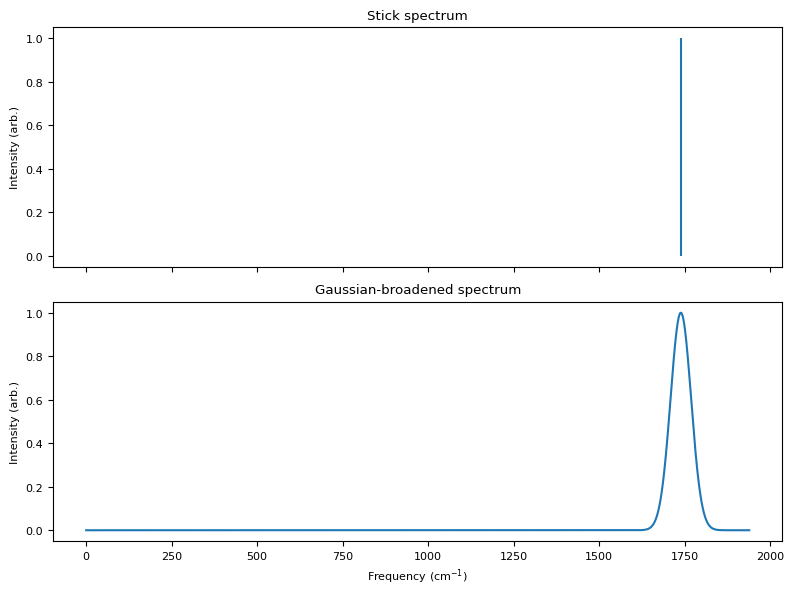

In [60]:
positive_freqs = vib_freqs[vib_freqs > 0]
if len(positive_freqs) == 0:
    print("No positive vibrational frequencies found after removing translational/rotational modes.")
    print("The molecule may not be properly optimized, or the model may give unstable modes for this geometry.")
else:
    x = np.linspace(0.0, positive_freqs.max() + 200.0, 3000)
    sigma = 30.0
    y = np.zeros_like(x)
    for nu in positive_freqs:
        y += np.exp(-0.5 * ((x - nu) / sigma) ** 2)

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axes[0].vlines(positive_freqs, 0, 1)
    axes[0].set_ylabel("Intensity (arb.)")
    axes[0].set_title("Stick spectrum")
    axes[1].plot(x, y)
    axes[1].set_xlabel("Frequency (cm$^{-1}$)")
    axes[1].set_ylabel("Intensity (arb.)")
    axes[1].set_title("Gaussian-broadened spectrum")
    fig.tight_layout()

mode_report = zpe_result["zpe_report"]
rot_report = zpe_result["rotational_report"]
print(f"Target ZPE          : {mode_report['target_total_eV']:.6f} eV")
print(f"Modal total energy  : {mode_report['modal_total_eV']:.6f} eV")
print(f"Modal kinetic energy: {mode_report['modal_kinetic_eV']:.6f} eV")
print(f"Modal potential     : {mode_report['modal_potential_eV']:.6f} eV")
print(f"External leakage    : {mode_report['external_leak_eV']:.6e} eV")
if rot_report["applied"]:
    print(f"Target rotational energy : {rot_report['target_energy_eV']:.6f} eV")
    print(f"Sampled rotational energy: {rot_report['sampled_energy_eV']:.6f} eV")


## Prepare and inspect the slab

First we build or load the slab, optionally relax it, and visualize the prepared structure. Thermalization, if requested, is handled in the next step as a separate stage.


In [61]:
SURFACE_SOURCE = "build"                                # 'build' to generate a slab, 'load' to read a slab file.

# Option 1: build directly in the notebook
SLAB_BUILDER = "graphite"                              # Slab builder: graphite, fcc111, fcc100, fcc110, bcc100/bcc001, bcc110, bcc111, hcp0001.
SLAB_SYMBOL = "C"                                      # Chemical symbol used by the builder when relevant.
SLAB_SIZE = (4, 4, 3)                                  # Supercell size for the slab builder.
SLAB_VACUUM = 20.0                                     # Vacuum spacing in angstroms.
SLAB_A = None                                          # Optional lattice parameter a; set this for BCC metals such as W if needed.
SLAB_C = None                                          # Optional interlayer/c lattice parameter.
SURFACE_CRYSTALSTRUCTURE = "fcc"                         # Used only when SLAB_BUILDER="surface"; e.g. "fcc", "bcc", "hcp".
SURFACE_MILLER = (1, 1, 0)                              # Used only when SLAB_BUILDER="surface".

# Option 2: load from file
SURFACE_PATH = Path("path/to/your/slab.xyz")          # Input slab file if SURFACE_SOURCE='load'.
SURFACE_FORMAT = None                                   # Force the file format, or None for ASE auto-detection.

RELAX_SURFACE = True                                    # Relax the slab before thermalization/impact.
RELAX_FMAX = 0.02                                       # Force convergence threshold for slab optimization (eV/A).
RELAX_MAX_STEPS = 200                                   # Maximum number of optimization steps for the slab.
WRITE_OPTIMIZED_SURFACE = True                          # Save the optimized slab geometry.
OPTIMIZED_SURFACE_PATH = OUTPUTS_DIR / "optimized_surface.xyz"  # Output path for the optimized slab.
SHOW_PREPARED_SURFACE = True                            # Visualize the slab after build/load and optional optimization.

THERMALIZE_SURFACE = True                              # Run a short NVT thermalization before the final NVE launch.
THERMALIZE_TEMPERATURE_K = 100.0                        # Target temperature for slab thermalization.
THERMALIZE_TIMESTEP_FS = 0.5                            # MD time step for the thermalization run.
THERMALIZE_STEPS = 50                                  # Number of thermalization MD steps.
THERMALIZE_TRAJ_INTERVAL = 1                            # Save one thermalization trajectory frame every N steps.
THERMALIZE_LOG_INTERVAL = 1                            # Write one thermalization log line every N steps.
THERMALIZATION_XYZ_PATH = OUTPUTS_DIR / "surface_thermalization.xyz"  # Exported XYZ trajectory for the slab thermalization.
THERMALIZED_SNAPSHOT_MODE = "random"                   # 'last', 'random', or 'index' for selecting the launch snapshot.
THERMALIZED_SNAPSHOT_SEED = 1234                         # Seed used when THERMALIZED_SNAPSHOT_MODE='random'.
THERMALIZED_SNAPSHOT_INDEX = None                       # Explicit snapshot index if THERMALIZED_SNAPSHOT_MODE='index'.
SHOW_THERMALIZED_SURFACE = True                         # Visualize the selected thermalized slab snapshot.

FIX_BOTTOM = True                                       # Freeze the bottom slab layers during relaxation.
BOTTOM_THICKNESS = 1.5                                  # Thickness of the frozen bottom region in angstroms.


In [62]:
if SURFACE_SOURCE == "build":
    slab_atoms = build_slab(builder=SLAB_BUILDER, symbol=SLAB_SYMBOL, size=SLAB_SIZE, vacuum=SLAB_VACUUM, a=SLAB_A, c=SLAB_C, crystalstructure=SURFACE_CRYSTALSTRUCTURE, miller=SURFACE_MILLER)
    surface_atoms, _, _, _ = prepare_surface(
        calc,
        surface_atoms=slab_atoms,
        optimize=RELAX_SURFACE,
        optimize_fmax=RELAX_FMAX,
        optimize_max_steps=RELAX_MAX_STEPS,
        fix_bottom=FIX_BOTTOM,
        bottom_thickness=BOTTOM_THICKNESS,
        thermalize=False,
        optimized_surface_path=OPTIMIZED_SURFACE_PATH if WRITE_OPTIMIZED_SURFACE else None,
    )
elif SURFACE_SOURCE == "load":
    surface_atoms, _, _, _ = prepare_surface(
        calc,
        surface_path=SURFACE_PATH,
        fmt=SURFACE_FORMAT,
        optimize=RELAX_SURFACE,
        optimize_fmax=RELAX_FMAX,
        optimize_max_steps=RELAX_MAX_STEPS,
        fix_bottom=FIX_BOTTOM,
        bottom_thickness=BOTTOM_THICKNESS,
        thermalize=False,
        optimized_surface_path=OPTIMIZED_SURFACE_PATH if WRITE_OPTIMIZED_SURFACE else None,
    )
else:
    raise ValueError("SURFACE_SOURCE must be 'build' or 'load'.")

selected_surface_atoms = surface_atoms.copy()
thermalization_traj_path = None
selected_snapshot_index = None
n_thermalized_frames = None

print(surface_atoms)
summarize_slab_geometry(surface_atoms, label="Prepared slab")
if SHOW_PREPARED_SURFACE:
    show_atoms(surface_atoms, label="prepared_surface")


Surface optimization: 0step [00:00, ?step/s]

Atoms(symbols='C96', pbc=True, cell=[[9.84, 0.0, 0.0], [-4.92, 8.521689973238876, 0.0], [0.0, 0.0, 51.7]], constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]), calculator=SumCalculator(...))
Prepared slab summary
  Formula              : C96
  Number of atoms      : 96
  Cell lengths (A)     : a=9.8400, b=9.8400, c=51.7000
  Cell angles (deg)    : alpha=90.00, beta=90.00, gamma=120.00
  PBC                  : (True, True, True)
  Builder              : graphite
  Lattice constant (A) : 2.4600
  Interlayer spacing   :
    layer 1-2 : 3.6323 A
    layer 2-3 : 3.6275 A
  Shortest distances   :
     39- 40 (C-C) : 1.4199 A
     32- 63 (C-C) : 1.4199 A
     47- 48 (C-C) : 1.4199 A
     55- 56 (C-C) : 1.4199 A
     38- 61 (C-C) : 1.4199 A
     37- 46 (C-C) : 1.4199 A
     49- 58 (C-C) : 1.4199 A
     34- 57 (C-C) : 1.4199 A


## Thermalize the slab if needed

If thermalization is enabled, a short NVT trajectory is run, then a snapshot is selected for the final NVE launch. You can take the last frame, a random frame, or an explicit index.


In [63]:
if THERMALIZE_SURFACE:
    _, thermalization_traj_path, selected_snapshot_index, n_thermalized_frames = prepare_surface(
        calc,
        surface_atoms=surface_atoms,
        optimize=False,
        fix_bottom=False,
        thermalize=True,
        thermalize_temperature_K=THERMALIZE_TEMPERATURE_K,
        thermalize_timestep_fs=THERMALIZE_TIMESTEP_FS,
        thermalize_steps=THERMALIZE_STEPS,
        thermalize_traj_interval=THERMALIZE_TRAJ_INTERVAL,
        thermalize_log_interval=THERMALIZE_LOG_INTERVAL,
        thermalized_snapshot_mode=THERMALIZED_SNAPSHOT_MODE,
        thermalized_snapshot_seed=THERMALIZED_SNAPSHOT_SEED,
        thermalized_snapshot_index=THERMALIZED_SNAPSHOT_INDEX,
    )
    selected_surface_atoms, selected_snapshot_index, n_thermalized_frames = select_trajectory_snapshot(
        thermalization_traj_path,
        mode=THERMALIZED_SNAPSHOT_MODE,
        random_seed=THERMALIZED_SNAPSHOT_SEED,
        frame_index=THERMALIZED_SNAPSHOT_INDEX,
    )
    selected_surface_atoms.calc = calc
    export_xyz(thermalization_traj_path, THERMALIZATION_XYZ_PATH)
    print(f"Thermalization trajectory: {thermalization_traj_path}")
    print(f"Thermalization XYZ       : {THERMALIZATION_XYZ_PATH}")
    print(f"Selected thermalized snapshot index: {selected_snapshot_index} / {n_thermalized_frames - 1}")
    if SHOW_THERMALIZED_SURFACE:
        show_atoms(selected_surface_atoms, label="thermalized_surface")
else:
    print("Thermalization disabled; using the prepared slab directly.")
    selected_surface_atoms = surface_atoms.copy()
    selected_surface_atoms.calc = calc


Surface thermalization [NVT (Nose-Hoover chain)]:   0%|          | 0/50 [00:00<?, ?step/s]

Thermalization trajectory: /Users/samuel/Desktop/postdoc_PhLAM/codes/Introduction_to_MACE/outputs/02_mace_molecule_surface_zpe/surface_thermalization.traj
Thermalization XYZ       : /Users/samuel/Desktop/postdoc_PhLAM/codes/Introduction_to_MACE/outputs/02_mace_molecule_surface_zpe/surface_thermalization.xyz
Selected thermalized snapshot index: 49 / 50


## Build the initial slab-molecule state and launch the NVE dynamics

After slab preparation and optional thermalization, the molecule is oriented and placed above the selected slab snapshot. The translational incident velocity is added only after the orientation step so the launch direction stays along the chosen incidence axis.

Optionally, the NVE run can stop early once the molecule has first moved below its launch height and then comes back to that initial height again, which is used here as a simple scattering criterion.


In [64]:
INCIDENT_ENERGY_EV = 1.0                               # Translational incident energy added to the molecular center of mass (eV).
INCIDENT_DIRECTION = (0.0, 0.0, -1.0)                  # Incident direction; the current default is along -Z.
MOLECULE_HEIGHT = 10.0                                  # Initial molecular COM height above the slab top layer (A).
XY_MODE = "center"                                    # 'center' to aim at the slab center, 'custom' for XY_TARGET.
XY_TARGET = None                                       # Custom (x, y) impact point when XY_MODE='custom'.
RANDOM_ORIENTATION = True                              # Randomly rotate the molecule before adding the incident velocity.
SHOW_COMBINED_INITIAL_STRUCTURE = True                 # Visualize the initial slab+molecule state before NVE.
TIMESTEP_FS = 1.0                                      # MD time step for the final NVE trajectory.
NSTEPS = 1000                                           # Maximum number of NVE steps.
TRAJ_INTERVAL = 1                                      # Save one NVE trajectory frame every N steps.
LOG_INTERVAL = 1                                      # Write one NVE log line every N steps.
XYZ_TRAJECTORY_PATH = OUTPUTS_DIR / "surface_md.xyz"  # Exported XYZ trajectory path.
SHOW_FINAL_STRUCTURE = True                            # Visualize the final MD frame.
STOP_ON_SCATTER = True                                 # Stop early when the molecule returns to its initial height above the surface.
SCATTER_HEIGHT_TOLERANCE = 0.05                        # Height tolerance for the scattering stop criterion (A).
REQUIRE_DESCENT_BEFORE_STOP = True                     # Require the molecule to descend first before allowing the stop.

molecule_atoms = place_molecule_above_slab(
    molecule_atoms,
    selected_surface_atoms,
    height=MOLECULE_HEIGHT,
    xy_mode=XY_MODE,
    xy_target=XY_TARGET,
    random_orientation=RANDOM_ORIENTATION,
    orientation_seed=ZPE_SEED + 1,
)
incident_velocity = velocity_from_incident_energy_eV(molecule_atoms, energy_eV=INCIDENT_ENERGY_EV, direction=INCIDENT_DIRECTION)
set_center_of_mass_velocity(molecule_atoms, incident_velocity)
print(f"Target molecular COM velocity : {incident_velocity * units.fs}")
print(f"Actual molecular COM velocity : {get_center_of_mass_velocity(molecule_atoms) * units.fs}")

system = build_slab_molecule_system(selected_surface_atoms, molecule_atoms, calc)
slab_indices = np.arange(len(selected_surface_atoms))
molecule_indices = np.arange(len(system) - len(molecule_atoms), len(system))
initial_molecule_height = get_molecule_height_above_surface(system, slab_indices, molecule_indices)
print(f"Initial molecular height above top layer: {initial_molecule_height:.4f} A")

stop_condition = None
scatter_state = None
if STOP_ON_SCATTER:
    stop_condition, scatter_state = make_scattering_stop_condition(
        slab_indices,
        molecule_indices,
        initial_height=initial_molecule_height,
        tolerance=SCATTER_HEIGHT_TOLERANCE,
        require_descent=REQUIRE_DESCENT_BEFORE_STOP,
    )

initial_system = system.copy()
initial_system.set_velocities(system.get_velocities().copy())

if SHOW_COMBINED_INITIAL_STRUCTURE:
    show_atoms(system, label="initial_system")

md_mode, traj_path, log_path, steps_run, stopped_early, stop_reason = run_md(
    system,
    timestep_fs=TIMESTEP_FS,
    nsteps=NSTEPS,
    traj_path=OUTPUTS_DIR / "surface_md.traj",
    log_path=OUTPUTS_DIR / "surface_md.log",
    traj_interval=TRAJ_INTERVAL,
    log_interval=LOG_INTERVAL,
    progress_desc="Slab-molecule NVE",
    stop_condition=stop_condition,
)
export_xyz(traj_path, XYZ_TRAJECTORY_PATH)
print(f"MD mode       : {md_mode}")
print(f"Trajectory    : {traj_path}")
print(f"XYZ trajectory: {XYZ_TRAJECTORY_PATH}")
print(f"Log file      : {log_path}")
print(f"Steps run     : {steps_run}")
if STOP_ON_SCATTER:
    print(f"Scattering stop enabled : {STOP_ON_SCATTER}")
    print(f"Stopped early           : {stopped_early}")
    if scatter_state is not None:
        print(f"Final molecular height  : {scatter_state['current_height']:.4f} A")
        print(f"Stop step               : {scatter_state['stop_step']}")


Target molecular COM velocity : [ 0.          0.         -0.02535955]
Actual molecular COM velocity : [ 0.00000000e+00 -3.63440043e-19 -2.53595530e-02]
Initial molecular height above top layer: 10.0000 A


Slab-molecule NVE [NVE]:   0%|          | 0/1000 [00:00<?, ?step/s]

MD mode       : NVE
Trajectory    : /Users/samuel/Desktop/postdoc_PhLAM/codes/Introduction_to_MACE/outputs/02_mace_molecule_surface_zpe/surface_md.traj
XYZ trajectory: /Users/samuel/Desktop/postdoc_PhLAM/codes/Introduction_to_MACE/outputs/02_mace_molecule_surface_zpe/surface_md.xyz
Log file      : /Users/samuel/Desktop/postdoc_PhLAM/codes/Introduction_to_MACE/outputs/02_mace_molecule_surface_zpe/surface_md.log
Steps run     : 1000
Scattering stop enabled : True
Stopped early           : False
Final molecular height  : 9.8835 A
Stop step               : None


## MD summary


/var/folders/_6/kz2bqhzd79dbbpb_vyjf9y680000gp/T/ipykernel_85567/636356707.py:86: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  heatmap = axes[0].imshow(


Logged MD points                  : 1001
Molecule analysis frames          : 1002
Initial translational energy      : 1.000000 eV
Initial normal incident energy    : 1.000000 eV
Initial rotational energy         : 0.033280 eV
Initial rotational temperature    : 386.20 K
Final translational energy        : 0.253075 eV
Final normal incident energy      : 0.249501 eV
Final tangential translational KE : 0.003574 eV
Final rotational energy           : 0.021178 eV
Final rotational temperature      : 245.76 K
Final internal kinetic energy     : 0.091850 eV
Final molecule height             : 9.8835 A
Max rotational temperature        : 1217.39 K
Max rotational energy             : 0.104906 eV
Initial sum over vibrational modes: 0.107803 eV
Final sum over vibrational modes  : 0.105823 eV
Max absolute ZPE drift            : 0.071565 eV
Largest vibrational mode energy changes:
  mode  1 ( 1738.98 cm^-1) : initial=0.107803 eV  final=0.105823 eV  delta=-0.001980 eV


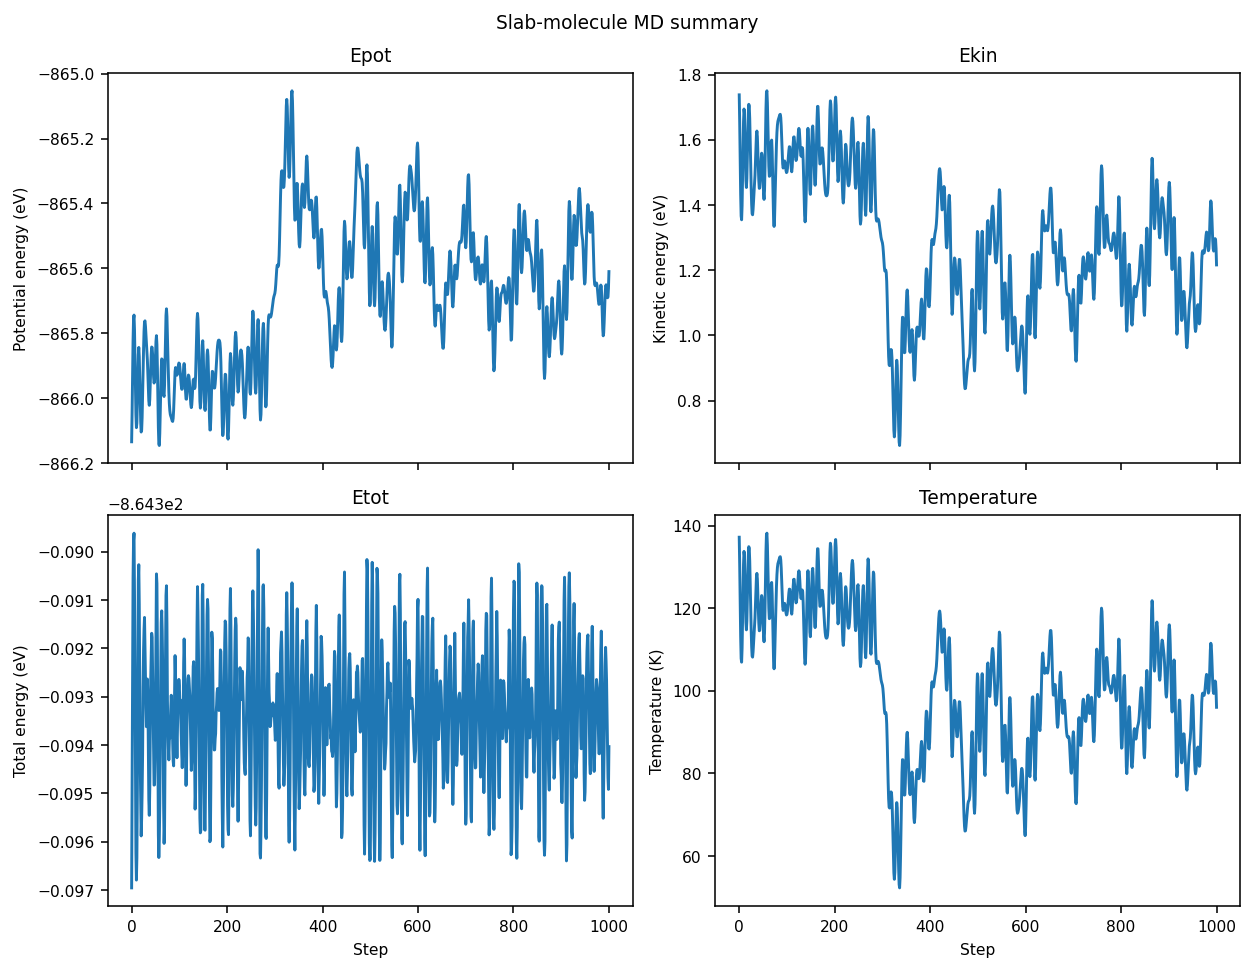

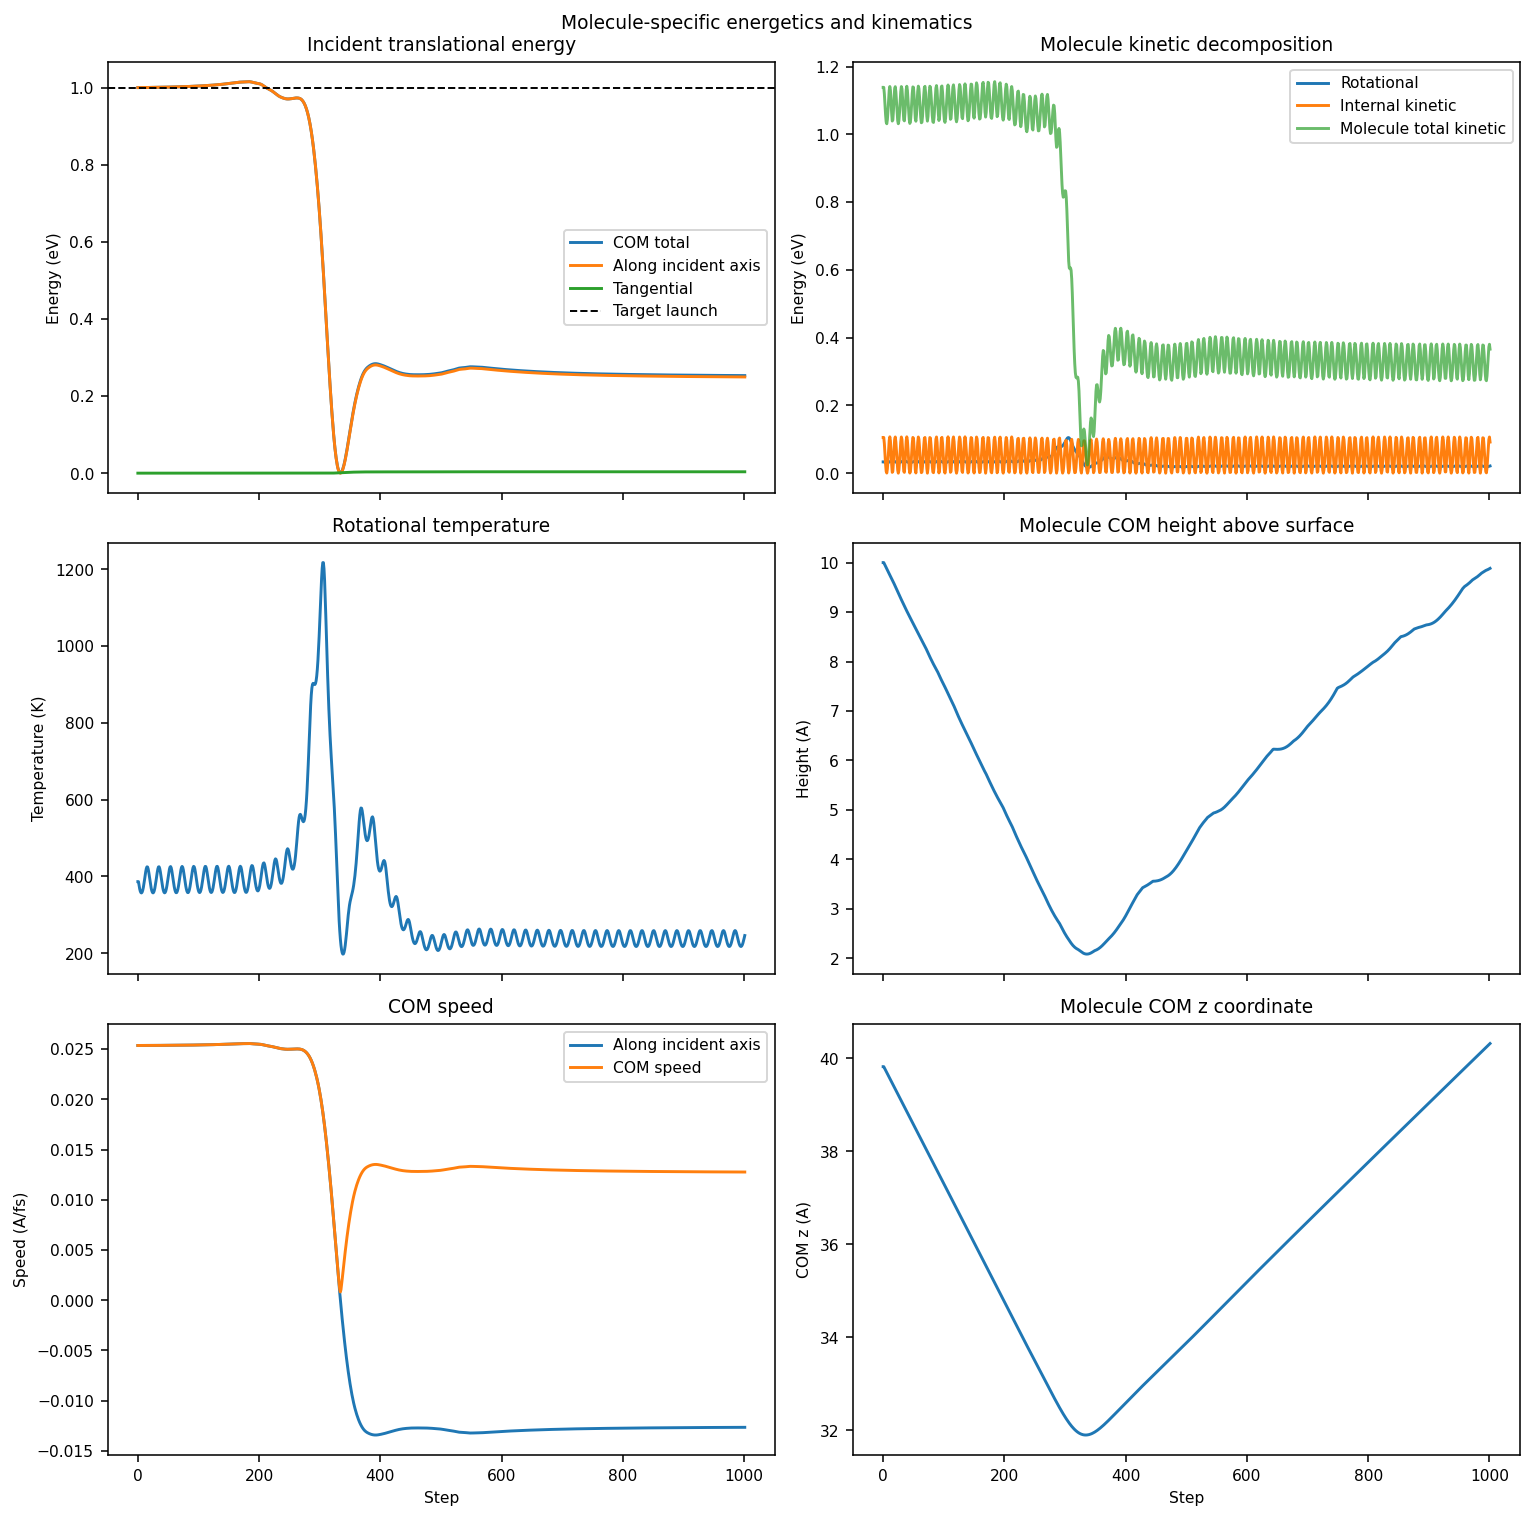

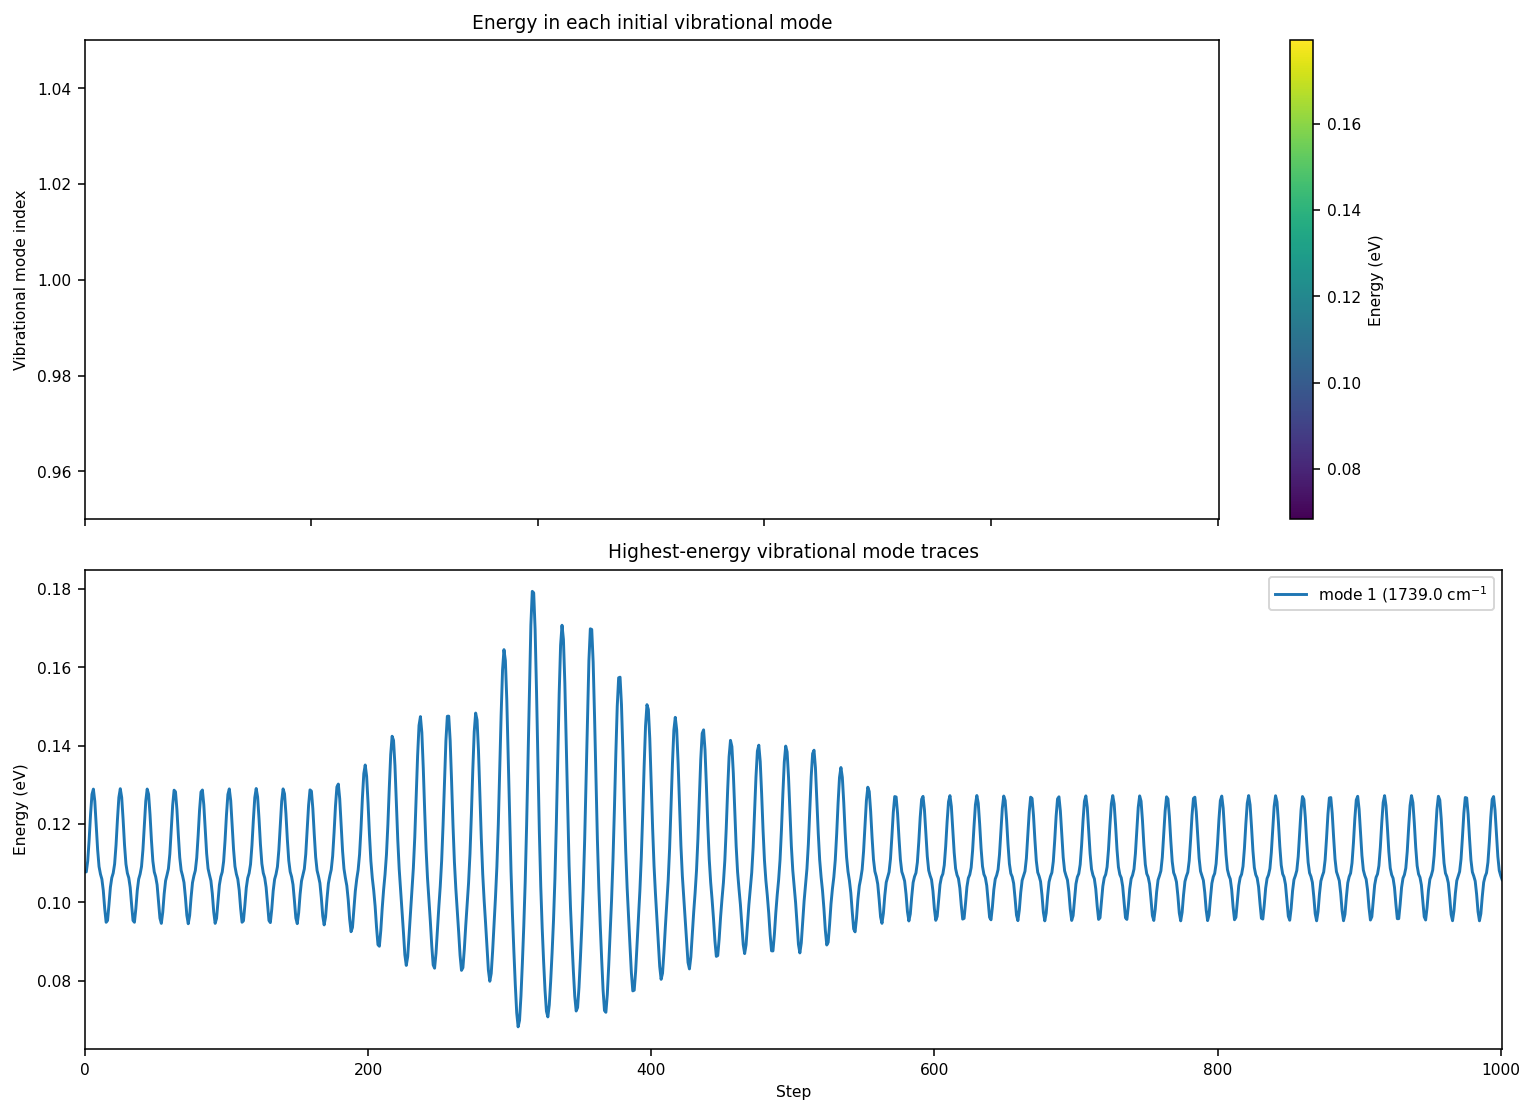

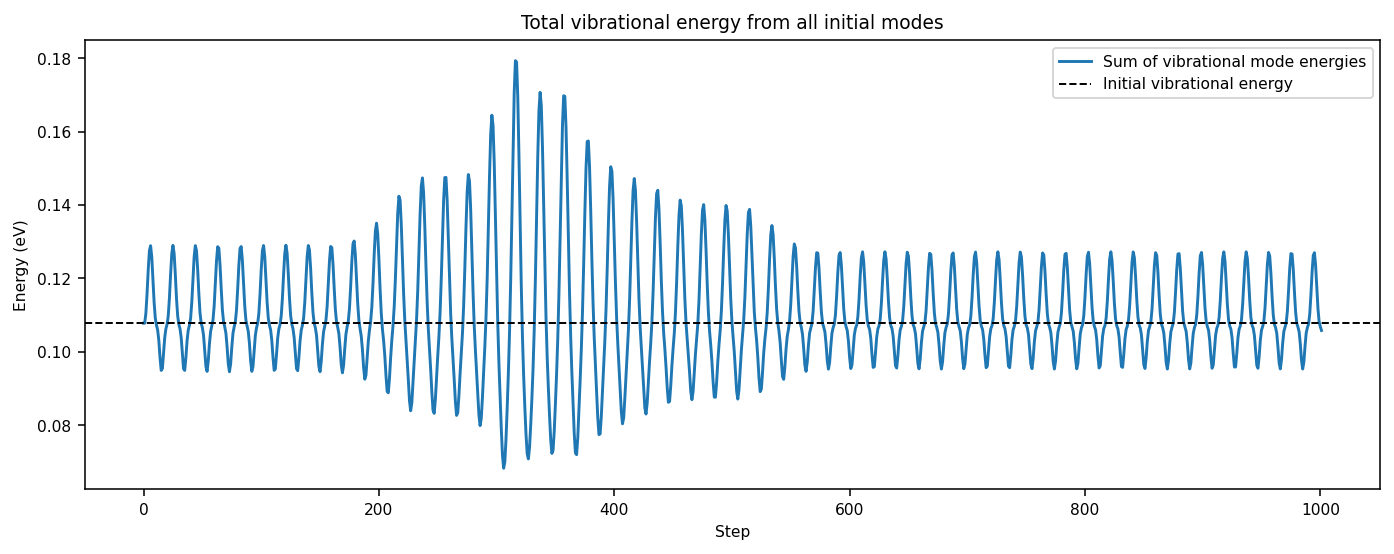

In [65]:
log = parse_md_log(log_path)
last_frame = Trajectory(str(traj_path))[-1]
molecule_md = analyze_molecule_trajectory(
    traj_path,
    molecule_indices,
    slab_indices=slab_indices,
    timestep_fs=TIMESTEP_FS,
    traj_interval=TRAJ_INTERVAL,
    incident_direction=INCIDENT_DIRECTION,
    linear=zpe_result["effective_linear"],
    initial_atoms=initial_system,
)
mode_md = analyze_vibrational_mode_trajectory(
    traj_path,
    molecule_indices,
    reference_atoms=zpe_result["optimized_atoms"],
    eigvecs=zpe_result["eigvecs"],
    masses_dof=zpe_result["masses_dof"],
    eigvals=zpe_result["eigvals"],
    n_zero=zpe_result["n_zero"],
    timestep_fs=TIMESTEP_FS,
    traj_interval=TRAJ_INTERVAL,
    initial_atoms=initial_system,
)
mode_total = mode_md["vibrational_mode_total_eV"]
mode_initial = mode_total[0]
mode_final = mode_total[-1]
mode_delta = mode_final - mode_initial
mode_sum = mode_total.sum(axis=1)
top_mode_indices = np.argsort(np.max(mode_total, axis=0))[::-1][:min(6, mode_total.shape[1])]

fig, axes = plt.subplots(2, 2, figsize=(9, 7), dpi=140, sharex=True)
(ax1, ax2), (ax3, ax4) = axes
ax1.plot(log["steps"], log["epot"])
ax1.set_ylabel("Potential energy (eV)")
ax1.set_title("Epot")
ax2.plot(log["steps"], log["ekin"])
ax2.set_ylabel("Kinetic energy (eV)")
ax2.set_title("Ekin")
ax3.plot(log["steps"], log["etot"])
ax3.set_xlabel("Step")
ax3.set_ylabel("Total energy (eV)")
ax3.set_title("Etot")
ax4.plot(log["steps"], log["temp"])
ax4.set_xlabel("Step")
ax4.set_ylabel("Temperature (K)")
ax4.set_title("Temperature")
fig.suptitle("Slab-molecule MD summary", y=0.98)
fig.tight_layout()

fig, axes = plt.subplots(3, 2, figsize=(11, 11), dpi=140, sharex=True)
(ax1, ax2), (ax3, ax4), (ax5, ax6) = axes
ax1.plot(molecule_md["step"], molecule_md["translational_kinetic_eV"], label="COM total")
ax1.plot(molecule_md["step"], molecule_md["normal_kinetic_eV"], label="Along incident axis")
ax1.plot(molecule_md["step"], molecule_md["tangential_kinetic_eV"], label="Tangential")
ax1.axhline(INCIDENT_ENERGY_EV, color="k", linestyle="--", linewidth=1.0, label="Target launch")
ax1.set_ylabel("Energy (eV)")
ax1.set_title("Incident translational energy")
ax1.legend()
ax2.plot(molecule_md["step"], molecule_md["rotational_kinetic_eV"], label="Rotational")
ax2.plot(molecule_md["step"], molecule_md["internal_kinetic_eV"], label="Internal kinetic")
ax2.plot(molecule_md["step"], molecule_md["total_kinetic_eV"], label="Molecule total kinetic", alpha=0.7)
ax2.set_ylabel("Energy (eV)")
ax2.set_title("Molecule kinetic decomposition")
ax2.legend()
ax3.plot(molecule_md["step"], molecule_md["rotational_temperature_K"])
ax3.set_ylabel("Temperature (K)")
ax3.set_title("Rotational temperature")
ax4.plot(molecule_md["step"], molecule_md["height_A"])
ax4.set_ylabel("Height (A)")
ax4.set_title("Molecule COM height above surface")
ax5.plot(molecule_md["step"], molecule_md["normal_speed_A_fs"], label="Along incident axis")
ax5.plot(molecule_md["step"], molecule_md["com_speed_A_fs"], label="COM speed")
ax5.set_xlabel("Step")
ax5.set_ylabel("Speed (A/fs)")
ax5.set_title("COM speed")
ax5.legend()
ax6.plot(molecule_md["step"], molecule_md["com_z_A"])
ax6.set_xlabel("Step")
ax6.set_ylabel("COM z (A)")
ax6.set_title("Molecule COM z coordinate")
fig.suptitle("Molecule-specific energetics and kinematics", y=0.98)
fig.tight_layout()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), dpi=140, sharex=True)
heatmap = axes[0].imshow(
    mode_total.T,
    aspect="auto",
    origin="lower",
    extent=[mode_md["step"][0], mode_md["step"][-1], 1, mode_total.shape[1]],
    cmap="viridis",
)
axes[0].set_ylabel("Vibrational mode index")
axes[0].set_title("Energy in each initial vibrational mode")
fig.colorbar(heatmap, ax=axes[0], label="Energy (eV)")
for mode_idx in top_mode_indices:
    axes[1].plot(mode_md["step"], mode_total[:, mode_idx], label=f"mode {mode_idx + 1} ({vib_freqs[mode_idx]:.1f} cm$^{{-1}}$")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Energy (eV)")
axes[1].set_title("Highest-energy vibrational mode traces")
axes[1].legend(ncol=2)
fig.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(10, 4), dpi=140, sharex=True)
ax.plot(mode_md["step"], mode_sum, label="Sum of vibrational mode energies")
ax.axhline(mode_sum[0], color="k", linestyle="--", linewidth=1.0, label="Initial vibrational energy")
ax.set_xlabel("Step")
ax.set_ylabel("Energy (eV)")
ax.set_title("Total vibrational energy from all initial modes")
ax.legend()
fig.tight_layout()

initial_idx = 0
final_idx = -1
print(f"Logged MD points                  : {len(log['steps'])}")
print(f"Molecule analysis frames          : {len(molecule_md['step'])}")
print(f"Initial translational energy      : {molecule_md['translational_kinetic_eV'][initial_idx]:.6f} eV")
print(f"Initial normal incident energy    : {molecule_md['normal_kinetic_eV'][initial_idx]:.6f} eV")
print(f"Initial rotational energy         : {molecule_md['rotational_kinetic_eV'][initial_idx]:.6f} eV")
print(f"Initial rotational temperature    : {molecule_md['rotational_temperature_K'][initial_idx]:.2f} K")
print(f"Final translational energy        : {molecule_md['translational_kinetic_eV'][final_idx]:.6f} eV")
print(f"Final normal incident energy      : {molecule_md['normal_kinetic_eV'][final_idx]:.6f} eV")
print(f"Final tangential translational KE : {molecule_md['tangential_kinetic_eV'][final_idx]:.6f} eV")
print(f"Final rotational energy           : {molecule_md['rotational_kinetic_eV'][final_idx]:.6f} eV")
print(f"Final rotational temperature      : {molecule_md['rotational_temperature_K'][final_idx]:.2f} K")
print(f"Final internal kinetic energy     : {molecule_md['internal_kinetic_eV'][final_idx]:.6f} eV")
print(f"Final molecule height             : {molecule_md['height_A'][final_idx]:.4f} A")
print(f"Max rotational temperature        : {np.nanmax(molecule_md['rotational_temperature_K']):.2f} K")
print(f"Max rotational energy             : {np.nanmax(molecule_md['rotational_kinetic_eV']):.6f} eV")
print(f"Initial sum over vibrational modes: {mode_sum[initial_idx]:.6f} eV")
print(f"Final sum over vibrational modes  : {mode_sum[final_idx]:.6f} eV")
print(f"Max absolute ZPE drift            : {np.max(np.abs(mode_sum - mode_sum[initial_idx])):.6f} eV")
print("Largest vibrational mode energy changes:")
for mode_idx in np.argsort(np.abs(mode_delta))[::-1][:min(8, len(mode_delta))]:
    print(f"  mode {mode_idx + 1:2d} ({vib_freqs[mode_idx]:8.2f} cm^-1) : initial={mode_initial[mode_idx]:.6f} eV  final={mode_final[mode_idx]:.6f} eV  delta={mode_delta[mode_idx]:+.6f} eV")


## Interactive trajectory

The interactive viewer is intentionally disabled in the saved notebook because it has been unstable in some notebook frontends.

If you want to try it manually after the MD run, you can execute:

```python
make_interactive_trajectory_viewer(traj_path, label="md")
```


In [66]:
# Interactive viewer intentionally left disabled in the saved notebook.
